In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

In [3]:
from library.utils import fontstyle, style_map

In [4]:
from collections import defaultdict
import sinter

In [5]:
# Load stim stats

csv_filename = PROJ_ROOT_PATH / "notebooks" / "ler" / "ler_readout.csv"

stats = sinter.read_stats_from_csv_files(csv_filename)
print(f"Loaded {len(stats)} simulation tasks.")

Loaded 30 simulation tasks.


In [6]:
from collections import defaultdict
from itertools import count
from scipy.optimize import curve_fit
import numpy as np

def get_required_distance(target_ler, d_vals, ler_vals):
    # try to find the nearest distance from the experiment results
    try:
        d_req = next(d for (d, ler) in zip(d_vals, ler_vals) if (ler <= target_ler))
    except:
        # derive the distance with the extrapolation (fitting)
        ## fitting
        def exp_decay(d, A, alpha): # NOTE: Use another fitting function if you want
            return A*np.exp(-alpha*d)
        (A_fit, alpha_fit), _ = curve_fit(exp_decay, d_vals, ler_vals)
        # find 
        d_req = next(d for d in count(3,2) if exp_decay(d, A_fit, alpha_fit) <= target_ler)

    return d_req

In [7]:
# input
target_ler = 1e-3

# parsing
grouped = defaultdict(list)
for s in stats:
    md = s.json_metadata
    ms_p = md.get('meas_error')  
    d = md.get('distance')
    ler = float(s.errors / s.shots)
    grouped[ms_p].append((d, ler))

result = []
for ms_p, val_list in sorted(grouped.items()):
    d_list = [d for (d, _) in val_list]
    ler_list = [ler for (_, ler) in val_list]
    d_req = get_required_distance(target_ler, d_list, ler_list)
    pq_per_lq = 2*(d_req**2)-1
    result.append({"meas_error": ms_p, "d_req": d_req, "pq_per_lq": pq_per_lq})

for res in result:
    print(res)

{'meas_error': 0.008, 'd_req': 15, 'pq_per_lq': 449}
{'meas_error': 0.016, 'd_req': 17, 'pq_per_lq': 577}
{'meas_error': 0.024, 'd_req': 21, 'pq_per_lq': 881}
{'meas_error': 0.032, 'd_req': 27, 'pq_per_lq': 1457}
{'meas_error': 0.04, 'd_req': 39, 'pq_per_lq': 3041}
{'meas_error': 0.048, 'd_req': 59, 'pq_per_lq': 6961}


In [8]:
# input
target_ler = 1e-3

# parsing
grouped = defaultdict(list)
for s in stats:
    md = s.json_metadata
    ms_p = md.get('meas_error')  
    d = md.get('distance')
    ler = float(s.errors / s.shots)
    grouped[ms_p].append((d, ler))

result = []
for ms_p, val_list in sorted(grouped.items()):
    d_list = [d for (d, _) in val_list]
    ler_list = [ler for (_, ler) in val_list]
    d_req = get_required_distance(target_ler, d_list, ler_list)
    pq_per_lq = 2*(d_req**2)-1
    result.append({"meas_error": ms_p, "d_req": d_req, "pq_per_lq": pq_per_lq})

for res in result:
    print(res)

{'meas_error': 0.008, 'd_req': 15, 'pq_per_lq': 449}
{'meas_error': 0.016, 'd_req': 17, 'pq_per_lq': 577}
{'meas_error': 0.024, 'd_req': 21, 'pq_per_lq': 881}
{'meas_error': 0.032, 'd_req': 27, 'pq_per_lq': 1457}
{'meas_error': 0.04, 'd_req': 39, 'pq_per_lq': 3041}
{'meas_error': 0.048, 'd_req': 59, 'pq_per_lq': 6961}


In [9]:
meas_error = [res['meas_error'] for res in result]
pq_per_lq = [res['pq_per_lq'] for res in result]

NPQ = {
    "HEMT (Baseline)": 778,
    "HEMT-HP-Mn": 874,
    "HEMT-NP-Mn": 1677,
    "HEMT-LP-Mn": 3899,
    "HEMT-LP-YBCO": 3956,
    "SIS-9w-YBCO": 4135,
}

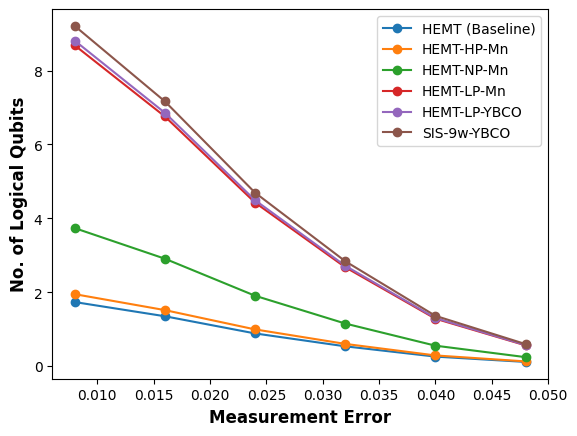

In [28]:
LQ_dict = {}
for label, val in NPQ.items():
    LQ = [val/rate for rate in  pq_per_lq]
    plt.plot(meas_error, LQ, marker='o', label=label)
    LQ_dict[label] = LQ

# plt.xticks(meas_errors,meas_errors)
# plt.xscale('log')
plt.xlabel("Measurement Error",fontsize = 'large',weight = 'bold')
plt.ylabel("No. of Logical Qubits", fontsize = 'large',weight = 'bold')
plt.legend()
plt.savefig(f"./LER.png",dpi=300)

In [29]:
from library.utils import fontstyle, style_map
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

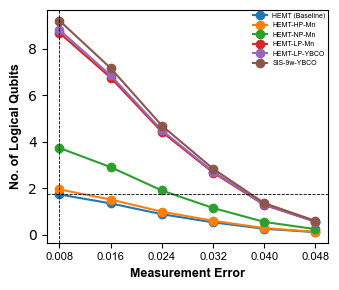

In [32]:
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5, 3))

for label, val in NPQ.items():
    LQ = [val/rate for rate in  pq_per_lq]
    ax.plot(meas_error, LQ, marker='o', label=label)

ax.set_xticks(meas_error)
for label in ax.get_xticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_xlabel("Measurement Error",fontproperties=axis_label_font)
ax.set_ylabel("No. of Logical Qubits", fontproperties=axis_label_font)
ax.legend(ncol=1, 
          bbox_to_anchor=(1,1),
          loc='upper right',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.axhline(y=LQ_dict['HEMT (Baseline)'][0], color='k', linestyle='--',linewidth=0.6)
ax.axvline(x=meas_error[0], color='k', linestyle='--',linewidth=0.6)

plt.tight_layout()
plt.savefig(f"./LER_readout.png",dpi=600)
plt.show()